# Step 0: Building the Character Sentiment Vectors
Turn each reflection into number, then stack them into per-character profiles.

**Run-vector** = one row = one person, one character, one run.
**Profile** = a participant's 10 run-vectors for one character, stacked.


Eventually outputs: `reflection_sentiment.csv` (every model's pos/neg) and `character_vectors_simple.csv` (the [pos,neg] baseline).

## Demarcation — which representation each step uses

The word "sentiment" refers to *different objects* in different steps. Keep this straight:

| Step / notebook | Object fed to the analysis | Type | Source |
|---|---|---|---|
| 0 · `00` | `valence = pos − neg` per model | **scalar** | fMRI transcripts |
| 1 · `01`/`01b`/`01d` | scalar valence, group-level | **scalar** | transcripts vs **SONA 16-item** survey |
| 2 · `02` | end-state scalar valence | **scalar** | transcripts vs **post-scan 35-item** survey |
| 3 · `03` | Twitter-RoBERTa `[pos,neg,neu]` (12-D in §3.5) | **3-D / 12-D probability vector** | transcripts — NOT the Step-1 scalar, NOT a USE embedding |
| 4a · `04a` | Jin's USE impression similarity | **512-d USE embedding** similarity | Jin's data (validation gate only) |
| 4b · `04b` | the 3-D/12-D sentiment cosine from Step 3 | **3-D / 12-D probability vector** | the brain test's "sentiment" ≠ the Step-1 validated scalar |
| 4c · `04c` | post-scan PC1 / positive_emotion / like | **survey ratings** | fMRI cohort, end-state |
| 5 · `05` | SONA group targets (PC1 / posE / like) | **survey ratings** | SONA cohort, group-level |
| 6 · `06` | `|Δ valence|` run-to-run change | **scalar** (delta) | transcripts |
| 7 · `07` | survey `like` | **survey ratings** | both cohorts |

**Three things to say out loud whenever "sentiment" comes up:**
1. Step 1 validated the **scalar** valence (cv-R² 0.34); Steps 3/4b feed the brain a **3-D `[pos,neg,neu]` cosine** — a different object, so a null in 4b is about that structure, not the validated scalar.
2. **USE embeddings** (512-d) are Jin's impression tool, used only in the 4a gate — not a sentiment measure.
3. Two survey instruments: **SONA 16-item** (behavioral cohort, run-resolved, group → Steps 1/5) and **post-scan 35-item** (fMRI cohort, end-state, individual → Steps 2/4c/7). "PC1" and "reliability" mean different things across them.

In [1]:
# pip install transformers torch nltk vaderSentiment flair pandas numpy scipy
import pandas as pd, numpy as np
from scipy.special import softmax
import warnings; warnings.filterwarnings("ignore")

CHARACTERS = ['randall', 'kevin', 'kate', 'jack']

## 0.1 Organize data/transcripts
One row per reflection 
from fMRI participants' spoken reflections recorded during the scanning session (transcript xlsx)


In [2]:
import glob, os, re, math
import pandas as pd
import numpy as np

# events.tsv onset + duration lookup AND order mapping
onset_lookup = {}
order_lookup = {} # maps (sub_id, run_num, order_index) -> character

for f in glob.glob(os.path.join("/Users/rheamadhogarhia/Desktop/CABLAB RESEARCH/independent ra work/part_4_summer_char_profiles/events.tsvs", "*events.tsv")):
    try:
        base = os.path.basename(f)
        sub_id = re.search(r'sub-\d+', base).group()
        run_num = int(re.search(r'task-(\d+)', base).group(1))
        df_tsv = pd.read_csv(f, sep='\t')
        
        run_chars = []
        for _, row in df_tsv.iterrows():
            event = str(row['event_type']).lower().strip()
            if event in CHARACTERS:
                dur = float(row['duration']) if 'duration' in df_tsv.columns and not pd.isna(row['duration']) else np.nan
                onset_val = float(row['onset'])
                onset_lookup[(sub_id, run_num, event)] = (onset_val, dur)
                run_chars.append((onset_val, event))
                
        # Sort chronologically to determine the 1st, 2nd, 3rd, 4th character order
        run_chars.sort()
        for i, (onset, char) in enumerate(run_chars):
            order_lookup[(sub_id, run_num, i + 1)] = char

    except Exception as e:
        print(f"Skipping {f}: {e}")

# transcription sheet
# --- transcript source (toggle to compare) ---
BASE_TX = "/Users/rheamadhogarhia/Desktop/CABLAB RESEARCH/independent ra work/part_4_summer_char_profiles/characterprofilesynchronygit/data/clean_from_jin"
TRANSCRIPT_PATH = f"{BASE_TX}/socialaha_transcribe_rhea_char_updated_clean_jin.csv"   # Jin's cleaned (canonical, preprocessed)
# TRANSCRIPT_PATH = f"{BASE_TX}/socialaha_transcribe_rhea_char.csv"                    # earlier version (with fillers)
file_path = TRANSCRIPT_PATH
all_data = []
CHAR_BY_INT = {1: "jack", 2: "kate", 3: "randall", 4: "kevin"}   # Jin's verified character coding

# Minimal change: Read the CSV directly and iterate through rows
df_csv = pd.read_csv(file_path)

for _, row in df_csv.iterrows():
    text = str(row['transcribe'])
    if text.lower() in ['nan', 'none', '']:
        continue
        
    clean_sub = f"sub-{row['subject']}"
    clean_run = int(row['run'])
    # Character identity from the transcript's own `character` column (Jin's 1..4 coding, verified);
    # fall back to the events-derived order map only if that column is missing.
    if 'character' in df_csv.columns and not pd.isna(row.get('character')):
        char_name = CHAR_BY_INT.get(int(row['character']), "")
    else:
        char_name = order_lookup.get((clean_sub, clean_run, int(row['order'])), "")
    
    if char_name not in CHARACTERS:
        continue
        
    true_onset, true_duration = onset_lookup.get((clean_sub, clean_run, char_name), (np.nan, np.nan))
    all_data.append({
        'Participant': clean_sub,
        'Run': clean_run,
        'Character': char_name,
        'Raw_Text': text,
        'WordCount': len(text.split()), 
        'Onset_Time': true_onset,
        'Duration': true_duration,
    })

df = pd.DataFrame(all_data)

df["Character"] = df["Character"].str.lower().str.strip()
df = df[df["Character"].isin(CHARACTERS)].reset_index(drop=True)
df["Raw_Text"] = df["Raw_Text"].fillna("")

print(f"{len(df)} reflections | {df.Participant.nunique()} participants | {df.Character.nunique()} characters")
df 

1272 reflections | 32 participants | 4 characters


,Participant,Run,Character,Raw_Text,WordCount,Onset_Time,Duration
0,sub-1001,1,jack,I don't really feel like I've learned that muc...,33,NaN,NaN
1,sub-1001,1,randall,Randall seems to be having a very emotional mo...,56,NaN,NaN
2,sub-1001,1,kevin,Kevin seems in one scene very emotional um and...,39,NaN,NaN
3,sub-1001,1,kate,Kate seems very upset. I saw that she sprained...,60,NaN,NaN
4,sub-1001,2,kate,Kate seems to be a little bit controlling but ...,41,NaN,NaN
...,...,...,...,...,...,...,...
1267,sub-3041,9,kate,"XXX any thoughts about Kate. Oh actually no, I...",109,NaN,NaN
1268,sub-3041,10,kate,"Yeah, also, like, Kate and Kevin are siblings?...",60,NaN,NaN
1269,sub-3041,10,jack,I think Jack was feeling really anxious in tha...,54,NaN,NaN
1270,sub-3041,10,kevin,"Yeah, Kevin seems to just be discontented with...",94,NaN,NaN


## 0.2 Score each reflection with each model

- Twitter-RoBERTa & RoBERTa-ZS: HF `softmax` over logits — HF Quick Tour (huggingface.co/docs/transformers/quicktour) + cardiffnlp model card (huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest)
- VADER: `polarity_scores` — cjhutto/vaderSentiment
- Flair: `TextClassifier` — flairnlp.github.io/docs/tutorial-basics/tagging-sentiment

*HAYOUNG OKed KEEPING FLAIR and will address single-label pos/neg mapping below*

In [3]:
#Model 1: Twitter-RoBERTa 
from transformers import AutoTokenizer, AutoModelForSequenceClassification
_TW = "cardiffnlp/twitter-roberta-base-sentiment-latest"
_tw_tok = AutoTokenizer.from_pretrained(_TW)
_tw_mdl = AutoModelForSequenceClassification.from_pretrained(_TW)

def score_twitter_roberta(text):
    enc = _tw_tok(text, return_tensors="pt", truncation=True, max_length=512)
    logits = _tw_mdl(**enc).logits.detach().numpy()[0]
    p = softmax(logits) # [negative, neutral, positive]
    return {"pos": float(p[2]), "neg": float(p[0]), "neu": float(p[1])}

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [4]:
#Model 2: RoBERTa zero-shot
from transformers import pipeline
_zs = pipeline("zero-shot-classification", model="roberta-large-mnli")

def score_roberta_zeroshot(text):
    out = _zs(text, candidate_labels=["positive", "negative"])
    d = dict(zip(out["labels"], out["scores"]))
    return {"pos": float(d.get("positive", 0.0)), "neg": float(d.get("negative", 0.0)), "neu": np.nan}

Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


In [5]:
#Model 3: VADER (lexicon baseline) — cjhutto/vaderSentiment
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
try:    _vader = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download("vader_lexicon"); _vader = SentimentIntensityAnalyzer()

def score_vader(text):
    s = _vader.polarity_scores(text)
    return {"pos": float(s["pos"]), "neg": float(s["neg"]), "neu": float(s["neu"])}

In [6]:
# Model 4: Flair returns ONE label + confidence, not independent pos/neg.  place the confidence on the matching pole, 0 on the other. Flair can't
# express ambivalence like the 3-way models — must decide if it belongs in a pos/neg vector. but what about both
from flair.data import Sentence
from flair.nn import Classifier
_flair = Classifier.load("sentiment")

def score_flair(text):
    snt = Sentence(text)
    if not text.strip(): return {"pos": np.nan, "neg": np.nan, "neu": np.nan}
    _flair.predict(snt)
    if not snt.labels: return {"pos": np.nan, "neg": np.nan, "neu": np.nan}
    lab = snt.labels[0]; conf = float(lab.score)
    return ({"pos": conf, "neg": 0.0, "neu": np.nan} if lab.value == "POSITIVE"
            else {"pos": 0.0, "neg": conf, "neu": np.nan})

In [7]:
# Models 5 & 6: SiEBERT (robust general RoBERTa-large sentiment) and BERTweet (Twitter-domain).
# BERTweet normalization needs pip install emoji
# Generic scorer maps by label NAME (pos/neg/neu) so index order never matters
# binary models (SiEBERT, 2-class) return neu = NaN.
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def _hf_scorer(model_name, maxlen=512):
    tok = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_name)
    id2lab = {i: str(mdl.config.id2label[i]).lower() for i in mdl.config.id2label}
    def score(text):
        if not str(text).strip():
            return {"pos": np.nan, "neg": np.nan, "neu": np.nan}
        enc = tok(str(text), return_tensors="pt", truncation=True, max_length=maxlen)
        p = softmax(mdl(**enc).logits.detach().numpy()[0])
        lab = {id2lab[i]: float(p[i]) for i in range(len(p))}
        def get(key):
            for name, v in lab.items():
                if key in name: return v
            return np.nan
        return {"pos": get("pos"), "neg": get("neg"), "neu": get("neu")}
    return score

score_siebert  = _hf_scorer("siebert/sentiment-roberta-large-english")
score_bertweet = _hf_scorer("finiteautomata/bertweet-base-sentiment-analysis", maxlen=128)

## citations

- **Twitter-RoBERTa** (`cardiffnlp/twitter-roberta-base-sentiment-latest`) — a transformer tuned on
  ~124M tweets; matched to informal, affect-laden speech. Benchmark: Barbieri et al. (2020), *TweetEval:
  Unified Benchmark and Comparative Evaluation for Tweet Classification*, Findings of EMNLP 2020.
- **RoBERTa zero-shot** (`roberta-large-mnli`) — a contextual transformer run as NLI, no sentiment
  fine-tuning. Base: Liu et al. (2019), *RoBERTa: A Robustly Optimized BERT Pretraining Approach*,
  arXiv:1907.11692.
- **VADER** — lexicon + rule baseline. Hutto & Gilbert (2014), *VADER: A Parsimonious Rule-based Model
  for Sentiment Analysis of Social Media Text*, ICWSM.
- **Flair** — DistilBERT single-label classifier (documented as binary / no neutral).

**SiEBERT** (`siebert/sentiment-roberta-large-english`) — i added as a strong general-purpose baseline
It is RoBERTa-large fine-tuned across 15 sentiment datasets and argued to generalize across text types
better than single-dataset models. Also serves as a control: a *general* (not Twitter) and *large*
model, so it tests whether the domain-matched model's edge is about domain vs size.
Hartmann, Heitmann, Siebert & Schamp (2023), *More than a Feeling: Accuracy and Application of Sentiment
Analysis*, International Journal of Research in Marketing 40(1):75-87, DOI 10.1016/j.ijresmar.2022.05.005.
Model: https://huggingface.co/siebert/sentiment-roberta-large-english

**BERTweet** (`finiteautomata/bertweet-base-sentiment-analysis`) — added as a *second, independent*
Twitter-domain transformer, so the "domain match helps" finding rests on two separate models rather
than one. Base BERTweet: Nguyen, Vu & Nguyen (2020), *BERTweet: A pre-trained language model for English
Tweets*, EMNLP 2020 (System Demonstrations), arXiv:2005.10200. Fine-tuning / toolkit: Pérez, Giudici &
Luque (2021), *pysentimiento: A Python Toolkit for Sentiment Analysis and SocialNLP tasks*,
arXiv:2106.09462. Model: https://huggingface.co/finiteautomata/bertweet-base-sentiment-analysis

In [8]:
MODELS = {"Twitter_RoB": score_twitter_roberta, "RoBERTa_ZS": score_roberta_zeroshot,
          "VADER": score_vader, "Flair": score_flair,
          "SiEBERT": score_siebert, "BERTweet": score_bertweet}

scored = df[["Participant", "Run", "Character", "Raw_Text"]].copy()
for name, fn in MODELS.items():
    print(f"scoring: {name}")
    recs = pd.DataFrame(list(df["Raw_Text"].map(fn)))
    recs.columns = [f"{name}_{c}" for c in recs.columns]
    scored = pd.concat([scored, recs], axis=1)

# length covariate (revision was added to control for reflection length downstream)
scored["WordCount"] = scored["Raw_Text"].fillna("").str.split().str.len()
import os; os.makedirs("results/scored", exist_ok=True)
scored.to_csv("results/scored/00__reflection_sentiment.csv", index=False)
print("wrote reflection_sentiment.csv", scored.shape); scored.head()

scoring: Twitter_RoB
scoring: RoBERTa_ZS
scoring: VADER
scoring: Flair
scoring: SiEBERT
scoring: BERTweet
wrote reflection_sentiment.csv (1272, 23)


,Participant,Run,Character,Raw_Text,Twitter_RoB_pos,Twitter_RoB_neg,Twitter_RoB_neu,RoBERTa_ZS_pos,RoBERTa_ZS_neg,RoBERTa_ZS_neu,...,Flair_pos,Flair_neg,Flair_neu,SiEBERT_pos,SiEBERT_neg,SiEBERT_neu,BERTweet_pos,BERTweet_neg,BERTweet_neu,WordCount
0,sub-1001,1,jack,I don't really feel like I've learned that muc...,0.014722,0.583887,0.401391,0.033728,0.966272,NaN,...,0.000000,0.955728,NaN,0.000777,0.999223,NaN,0.012925,0.051859,0.935217,33
1,sub-1001,1,randall,Randall seems to be having a very emotional mo...,0.059438,0.348121,0.592441,0.134204,0.865796,NaN,...,0.996607,0.000000,NaN,0.993690,0.006310,NaN,0.007569,0.384218,0.608213,56
2,sub-1001,1,kevin,Kevin seems in one scene very emotional um and...,0.282992,0.072702,0.644306,0.279990,0.720010,NaN,...,0.977687,0.000000,NaN,0.996345,0.003655,NaN,0.481485,0.005050,0.513465,39
3,sub-1001,1,kate,Kate seems very upset. I saw that she sprained...,0.005140,0.887712,0.107148,0.021230,0.978770,NaN,...,0.000000,0.999900,NaN,0.001849,0.998151,NaN,0.002294,0.968018,0.029688,60
4,sub-1001,2,kate,Kate seems to be a little bit controlling but ...,0.029626,0.306230,0.664144,0.531069,0.468931,NaN,...,0.670906,0.000000,NaN,0.994970,0.005030,NaN,0.116543,0.006275,0.877182,41


## 0.3 Build the baseline vector
`[positive, negative]` from Twitter-RoBERTa. baseline so any better vector must beat it on behavior fit

In [9]:
#0.3 Simple baseline vectors — one [pos, neg] per model
# Twitter-RoBERTa is the default ONLY because it won the EmoBank benchmark from a bit ago (REMMEBER TO FIND THAT NOTEBOOK)
#behavioral validation will pick the winner on OUR data,
# not EmoBank's. Each res file is a standalone "interpretable" baseline.

import os; os.makedirs("results/baselines", exist_ok=True)
baselines = {}
for m in MODELS:
    b = (scored[["Participant", "Run", "Character", f"{m}_pos", f"{m}_neg"]]
         .rename(columns={f"{m}_pos": "positive", f"{m}_neg": "negative"}))
    b.to_csv(f"results/baselines/00__character_vectors_simple_{m}.csv", index=False)
    baselines[m] = b
    print(f"wrote character_vectors_simple_{m}.csv  {b.shape}")

# keep the Twitter-RoBERTa one under the original name too, so 0.4 runs unchanged
simple = baselines["Twitter_RoB"]
simple.to_csv("results/baselines/00__character_vectors_simple.csv", index=False)
baselines["Twitter_RoB"].head()


wrote character_vectors_simple_Twitter_RoB.csv  (1272, 5)
wrote character_vectors_simple_RoBERTa_ZS.csv  (1272, 5)
wrote character_vectors_simple_VADER.csv  (1272, 5)
wrote character_vectors_simple_Flair.csv  (1272, 5)
wrote character_vectors_simple_SiEBERT.csv  (1272, 5)
wrote character_vectors_simple_BERTweet.csv  (1272, 5)


,Participant,Run,Character,positive,negative
0,sub-1001,1,jack,0.014722,0.583887
1,sub-1001,1,randall,0.059438,0.348121
2,sub-1001,1,kevin,0.282992,0.072702
3,sub-1001,1,kate,0.005140,0.887712
4,sub-1001,2,kate,0.029626,0.306230


## 0.4 examining all the baseline vectors
per-model checks, each model compared only to itself
Valence = pos − neg, one value per (participant, run, character)

In [10]:
#researched methods: within- vs between-person variance partition, reported as a ratio AND as
# ICC(1) (Shrout & Fleiss 1979; Bartko 1966) -- the named statistic for this split.
# Sets up RSA: Kriegeskorte, Mur & Bandettini (2008); Popal, Wang & Olson (2019).
val = scored[["Participant","Run","Character"]].copy()
for m in MODELS: val[m] = scored[f"{m}_pos"] - scored[f"{m}_neg"]
val = val.groupby(["Participant","Run","Character"]).mean(numeric_only=True).reset_index()
mods = list(MODELS)

# D1: does sentiment move across runs?
within  = val.groupby(["Participant","Character"])[mods].std(ddof=1).mean()
between = val.groupby(["Participant","Character"])[mods].mean().groupby("Character").std(ddof=1).mean()
print("D1  within/between ratio (>>1 = real within-person change):")
print((within/between).round(2).to_string())

# ICC(1): the named, citable version of "within vs between person" variance
# Intraclass correlation partitions variance into between- vs within-person components
# (Shrout & Fleiss 1979, Psychol Bull; Bartko 1966). ICC near 1 = stable trait-like
# differences between people; 
# ICC near 0 = variance is mostly within-person (change),
# We report ICC(1) per model per character.
def icc1(groups):
    # groups: list of arrays, one per person (their run values for one character)
    groups = [np.asarray(g, float) for g in groups if len(g) > 1]
    if len(groups) < 2: return np.nan
    k = np.mean([len(g) for g in groups])              # avg runs per person
    grand = np.mean([v for g in groups for v in g])
    msb = np.sum([len(g)*(g.mean()-grand)**2 for g in groups])/(len(groups)-1)
    msw = np.sum([((g-g.mean())**2).sum() for g in groups])/ \
          np.sum([len(g)-1 for g in groups])
    return (msb-msw)/(msb+(k-1)*msw) if (msb+(k-1)*msw)!=0 else np.nan

print("\nICC(1) per model (low ICC => variance is within-person => change-rich):")
for m in mods:
    iccs=[]
    for ch, sub in val.groupby("Character"):
        groups=[g[m].values for _,g in sub.groupby("Participant")]
        iccs.append(icc1(groups))
    print(f"  {m:12s} mean ICC(1) across characters: {np.nanmean(iccs):.3f}")

D1  within/between ratio (>>1 = real within-person change):
Twitter_RoB    2.25
RoBERTa_ZS     2.30
VADER          2.29
Flair          2.01
SiEBERT        2.33
BERTweet       2.11

ICC(1) per model (low ICC => variance is within-person => change-rich):
  Twitter_RoB  mean ICC(1) across characters: 0.079
  RoBERTa_ZS   mean ICC(1) across characters: 0.075
  VADER        mean ICC(1) across characters: 0.068
  Flair        mean ICC(1) across characters: 0.116
  SiEBERT      mean ICC(1) across characters: 0.071
  BERTweet     mean ICC(1) across characters: 0.099


In [11]:
# Methods: cross-model agreement. Spearman rank corr avoids assuming a shared numeric
# scale (cf. Walther et al. 2016).
# ONE NOTE: "% sign agreement" below is an intuitive,
# AD HOC descriptive; for a named inter-rater agreement coefficient use Krippendorff's
# alpha (Hayes & Krippendorff 2007, Communication Methods and Measures) should prob do it but def
# for the later writeup. this was mostly description

# D2: do models disagree enough to compare? (Spearman + sign agreement)
print("D2  cross-model Spearman:")
print(val[mods].corr("spearman").round(2).to_string())
signs = np.sign(val[mods].values)
print(f"\nall {len(mods)} models agree on sign: {(np.abs(np.nansum(signs,1))==len(mods)).mean()*100:.1f}%")

D2  cross-model Spearman:
             Twitter_RoB  RoBERTa_ZS  VADER  Flair  SiEBERT  BERTweet
Twitter_RoB         1.00        0.85   0.60   0.65     0.66      0.91
RoBERTa_ZS          0.85        1.00   0.54   0.59     0.67      0.83
VADER               0.60        0.54   1.00   0.40     0.44      0.61
Flair               0.65        0.59   0.40   1.00     0.63      0.67
SiEBERT             0.66        0.67   0.44   0.63     1.00      0.68
BERTweet            0.91        0.83   0.61   0.67     0.68      1.00

all 6 models agree on sign: 33.6%


In [12]:
# D2 (named statistic) -- interval Krippendorff's alpha across the classifiers. The citable
# inter-rater agreement coefficient (Krippendorff 2004; Hayes & Krippendorff 2007) that the ad-hoc
# "% sign agreement" above only approximates. Complete-data interval formula, no external dependency.
# [added to address the note "should prob do [Krippendorff's alpha]"]
import numpy as np, pandas as pd
_sc = pd.read_csv("results/scored/00__reflection_sentiment.csv")
_CLF = [c[:-4] for c in _sc.columns if c.endswith("_pos") and f"{c[:-4]}_neg" in _sc.columns]
_V = np.vstack([(_sc[f"{m}_pos"] - _sc[f"{m}_neg"]).values for m in _CLF]).astype(float)
_V = _V[:, ~np.isnan(_V).any(0)]                      # classifiers score every reflection -> complete
def _interval_alpha(V):
    m, N = V.shape
    Do = np.sum(m*np.sum(V**2, 0) - np.sum(V, 0)**2) / (N*m*(m-1)/2)
    a = V.ravel(); M = a.size
    De = (M*np.sum(a**2) - a.sum()**2) / (M*(M-1)/2)
    return 1 - Do/De
print(f"Krippendorff's alpha (interval, {len(_CLF)} models, {_V.shape[1]} reflections): {_interval_alpha(_V):.3f}")
print("Read: ~0.44 = moderate agreement -- the models are related but far from interchangeable,")
print("which is exactly why keeping multiple models (the D2 rationale) is justified.")

Krippendorff's alpha (interval, 6 models, 1272 reflections): 0.443
Read: ~0.44 = moderate agreement -- the models are related but far from interchangeable,
which is exactly why keeping multiple models (the D2 rationale) is justified.


## 0.4b viz

1. **Sentiment trajectories** — mean valence per character across runs (emotion-over-time; Hipson & Mohammad 2021, *PLOS ONE*, Utterance Emotion Dynamics).
2. **Model-agreement heatmap** — the D2 Spearman matrix as a representational-similarity-style heatmap (Kriegeskorte, Mur & Bandettini 2008, *Front. Syst. Neurosci.*).
3. **Within- vs between-person spread** — the D1 ratio as a bar chart, per model.

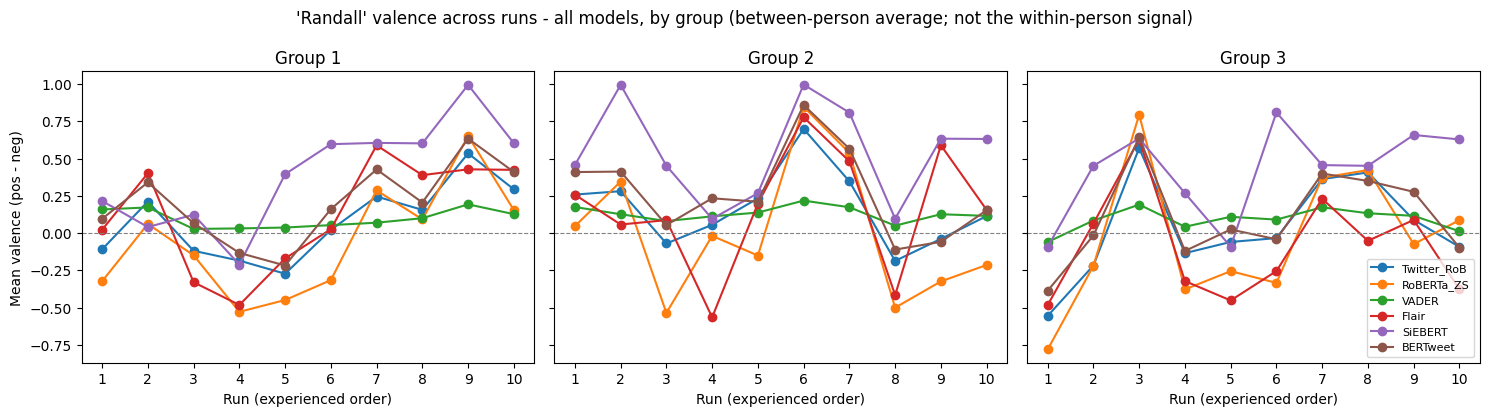

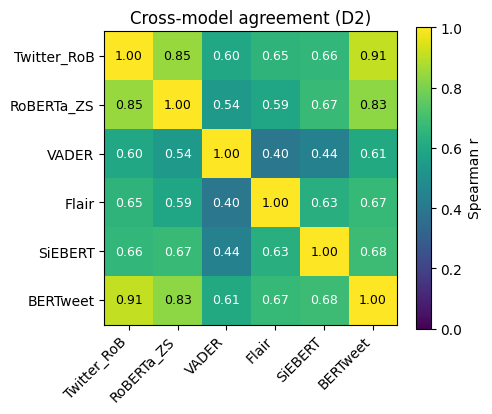

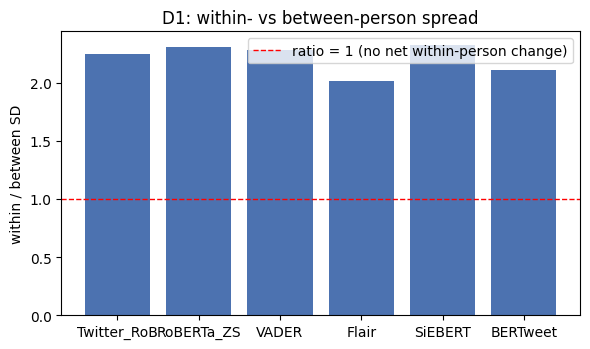

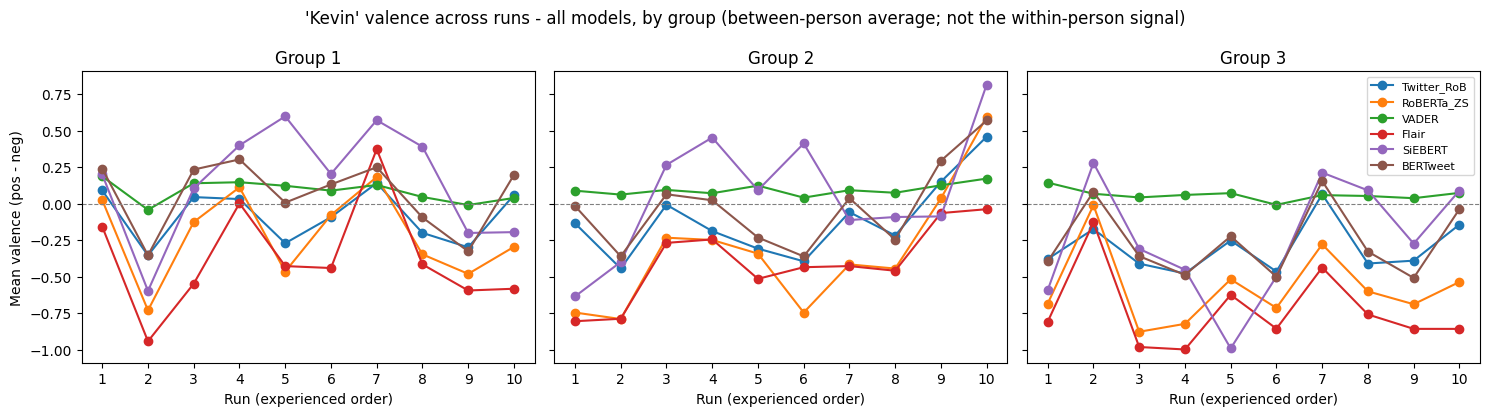

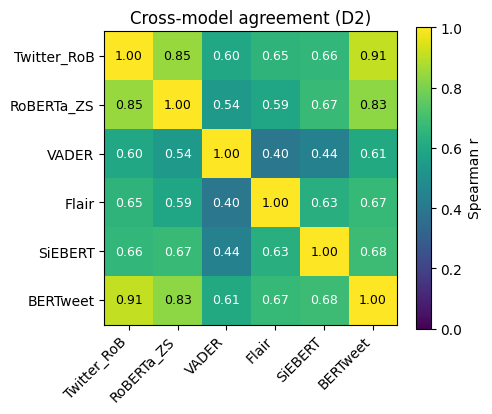

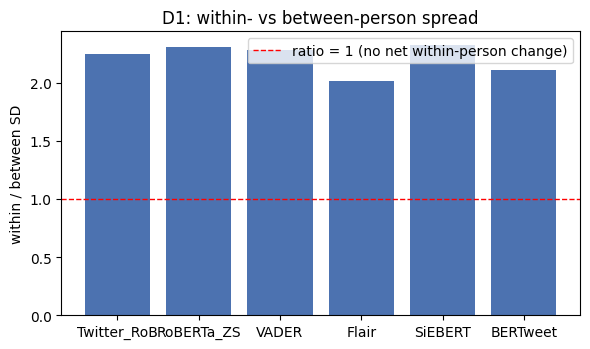

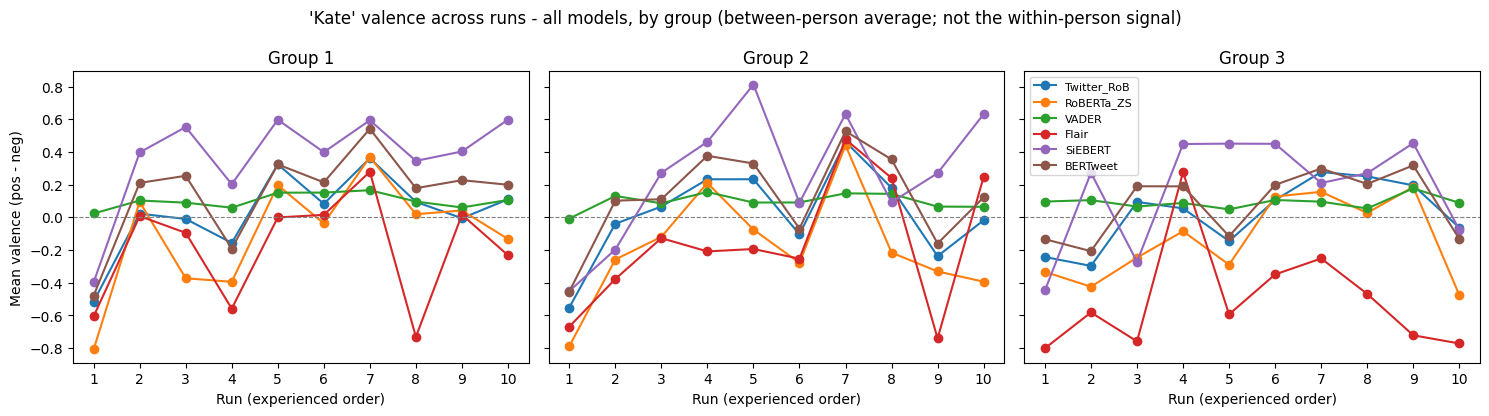

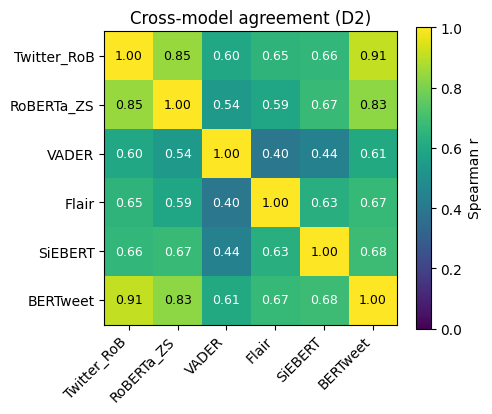

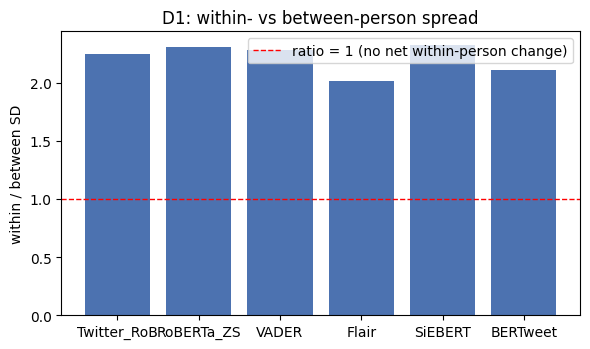

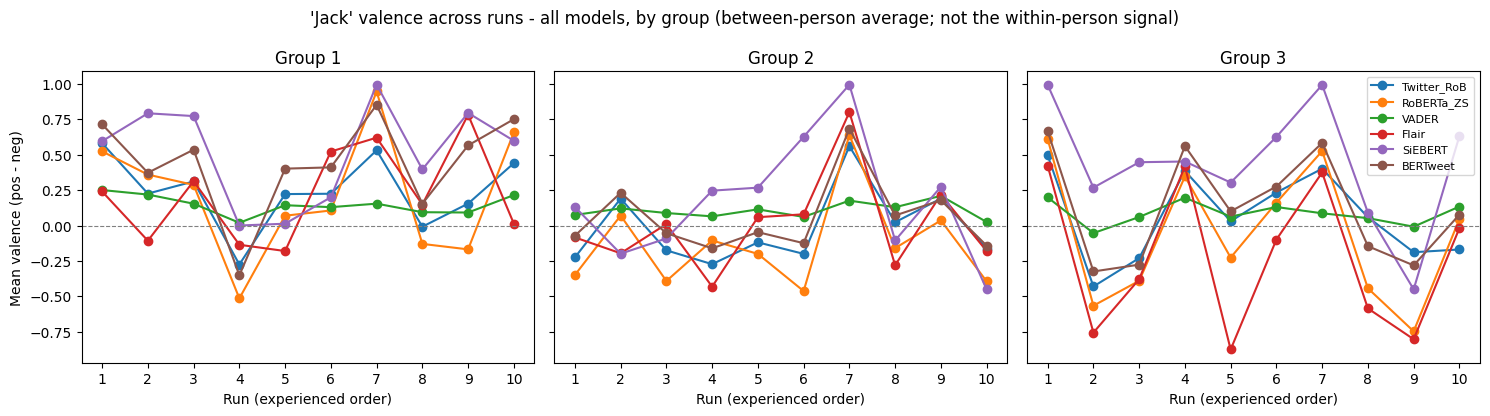

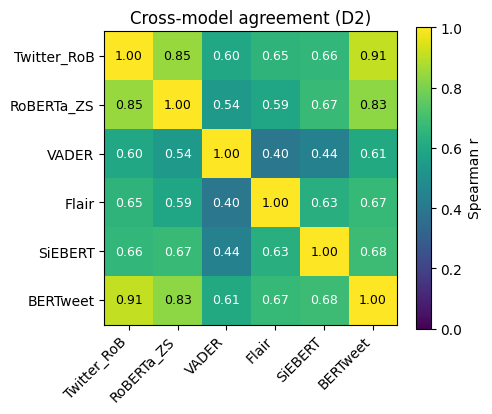

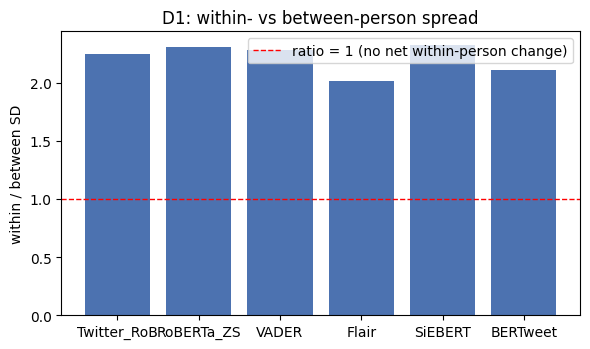

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# group from participant id: sub-1xxx/2xxx/3xxx -> group 1/2/3 (confirmed convention).
# Analysis is WITHIN group, so "run k" is only content-comparable within a group.
def _grp(pid):
    m = [c for c in str(pid) if c.isdigit()]
    return int(m[0]) if m else np.nan

# ---- 1. SENTIMENT TRAJECTORIES: ALL models, one character, FACETED BY GROUP ----
# (emotion-over-time; Hipson & Mohammad 2021, PLOS ONE)
# CAVEAT: this is a BETWEEN-person average at each run. A flat line here does NOT mean
# "no within-person change" (D1 already shows there is) 
# opposing within-person moves can cancel in the group mean. Faceting by group keeps each run content-comparable.
# old setup, was one at a time so set CHAR_TO_PLOT = "kate"   # change to any of jack/kate/kevin/randall START WITH KATE for example

for CHAR_TO_PLOT in CHARACTERS:
    tv = scored[["Participant","Run","Character"]].copy()
    for m in MODELS:
        tv[m] = scored[f"{m}_pos"] - scored[f"{m}_neg"]
    tv["group"] = tv["Participant"].map(_grp)
    tv = tv[tv.Character == CHAR_TO_PLOT]

    groups = sorted(tv["group"].dropna().unique())
    fig, axes = plt.subplots(1, len(groups), figsize=(5*len(groups), 4.2), sharey=True)
    if len(groups) == 1: axes = [axes]
    for ax, g in zip(axes, groups):
        sub = tv[tv.group == g]
        for m in MODELS:
            d = sub.groupby("Run")[m].mean()
            ax.plot(d.index, d.values, marker="o", label=m)
        ax.axhline(0, color="grey", lw=0.8, ls="--")
        ax.set_title(f"Group {int(g)}"); ax.set_xlabel("Run (experienced order)")
        ax.set_xticks(range(1,11))
    axes[0].set_ylabel("Mean valence (pos - neg)")
    axes[-1].legend(fontsize=8)
    fig.suptitle(f"'{CHAR_TO_PLOT.capitalize()}' valence across runs - all models, by group "
                f"(between-person average; not the within-person signal)")
    plt.tight_layout(); plt.show()

    # ---- 2. MODEL-AGREEMENT HEATMAP: D2 Spearman matrix as an RSA-style heatmap ----
    # (Kriegeskorte, Mur & Bandettini 2008)
    corr = val[mods].corr("spearman")
    fig, ax = plt.subplots(figsize=(5,4.2))
    im = ax.imshow(corr.values, vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(len(mods))); ax.set_xticklabels(mods, rotation=45, ha="right")
    ax.set_yticks(range(len(mods))); ax.set_yticklabels(mods)
    for a in range(len(mods)):
        for b in range(len(mods)):
            ax.text(b, a, f"{corr.values[a,b]:.2f}", ha="center", va="center",
                    color="white" if corr.values[a,b]<0.7 else "black", fontsize=9)
    fig.colorbar(im, label="Spearman r"); ax.set_title("Cross-model agreement (D2)")
    plt.tight_layout(); plt.show()

    # ---- 3. WITHIN/BETWEEN RATIO: the D1 result as a bar chart ----
    ratio = (within/between)
    fig, ax = plt.subplots(figsize=(6,3.6))
    ax.bar(ratio.index, ratio.values, color="#4C72B0")
    ax.axhline(1, color="red", ls="--", lw=1, label="ratio = 1 (no net within-person change)")
    ax.set_ylabel("within / between SD"); ax.set_title("D1: within- vs between-person spread")
    ax.legend(); plt.tight_layout(); plt.show()


## 0.4c Per-participant & summary figures/viz
these are = per-participant / summary views
of the Step-0 sentiment scores 


NOTEEE this can be run on
its own without re-executing the cells at the top of this notebook.

classifiers overlaid: ['Twitter_RoB', 'RoBERTa_ZS', 'VADER', 'Flair', 'SiEBERT', 'BERTweet']


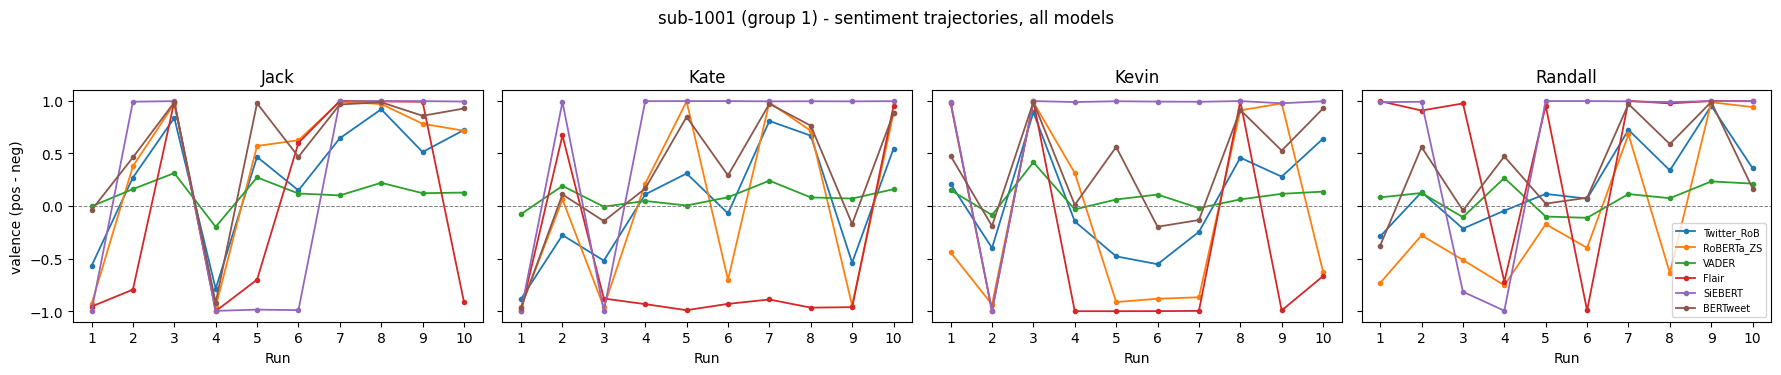

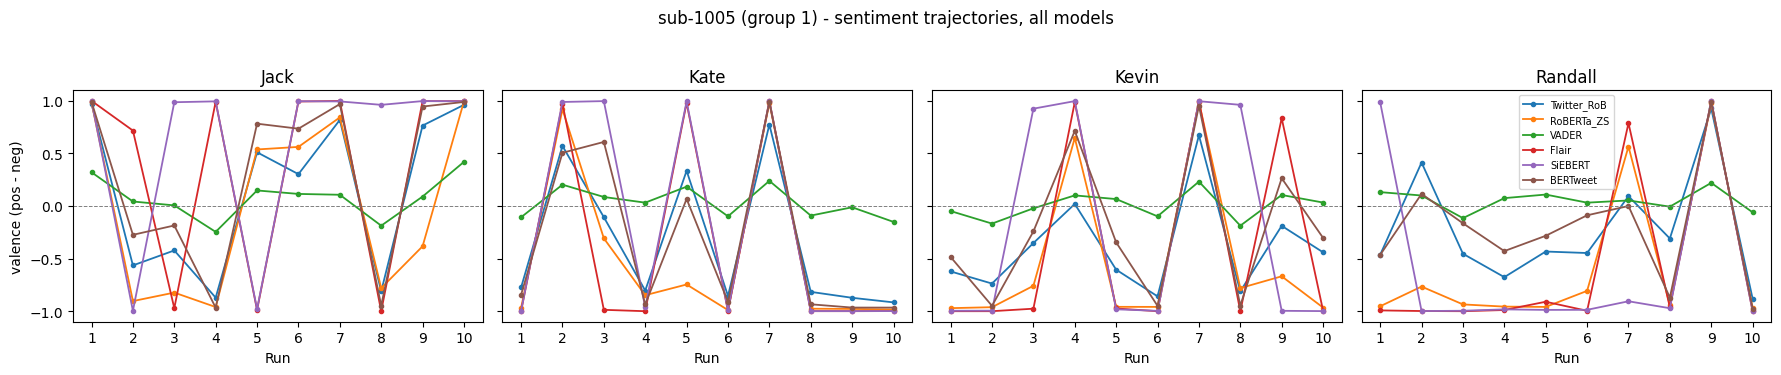

saved 32 per-participant figures -> results/figures/participant_trajectories


In [14]:
# 0.4c(i) Per-participant sentiment trajectories -- the "Kate plot" per person
# (former 02 section 2.1b). All classifier models overlaid across the 10 runs, one figure
# per fMRI participant. 
# loads results/scored/00__reflection_sentiment.csv.
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.cm as _cm
from pathlib import Path
CHARACTERS = ["jack", "kate", "kevin", "randall"]
FIG_DIR  = Path("results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
PART_DIR = FIG_DIR / "participant_trajectories"; PART_DIR.mkdir(exist_ok=True)
def _grp(pid):
    d = [c for c in str(pid) if c.isdigit()]; return int(d[0]) if d else np.nan

scored = pd.read_csv("results/scored/00__reflection_sentiment.csv")
scored["Character"] = scored["Character"].str.lower().str.strip()
scored = scored[scored["Run"].between(1, 10)]
# Derive the classifier list from whatever Step 0 actually scored (new models are picked up automatically).
CLASSIFIERS = [c[:-4] for c in scored.columns if c.endswith("_pos") and f"{c[:-4]}_neg" in scored.columns]
for m in CLASSIFIERS: scored[f"val_{m}"] = scored[f"{m}_pos"] - scored[f"{m}_neg"]
scored["group"] = scored["Participant"].map(_grp)
print("classifiers overlaid:", CLASSIFIERS)

mcolors = {m: _cm.tab10(i % 10) for i, m in enumerate(CLASSIFIERS)}
participants = sorted(scored.Participant.unique())
for pid in participants:
    p = scored[scored.Participant == pid]; gp = int(p.group.iloc[0])
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.6), sharey=True)
    for ax, ch in zip(axes, CHARACTERS):
        sub = p[p.Character == ch].sort_values("Run")
        for m in CLASSIFIERS:
            ax.plot(sub.Run, sub[f"val_{m}"], marker="o", ms=3, lw=1.3, color=mcolors[m], label=m)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.set_title(ch.capitalize()); ax.set_xlabel("Run"); ax.set_xticks(range(1, 11))
    axes[0].set_ylabel("valence (pos - neg)"); axes[-1].legend(fontsize=7)
    fig.suptitle(f"{pid} (group {gp}) - sentiment trajectories, all models", y=1.03)
    fig.tight_layout()
    fig.savefig(PART_DIR / f"00__{pid}.png", dpi=120, bbox_inches="tight")
    if pid in participants[:2]: plt.show()      # show two examples inline
    else: plt.close(fig)
print(f"saved {len(participants)} per-participant figures -> {PART_DIR}")

**full patricipant profile sheet** (former 2.1c).

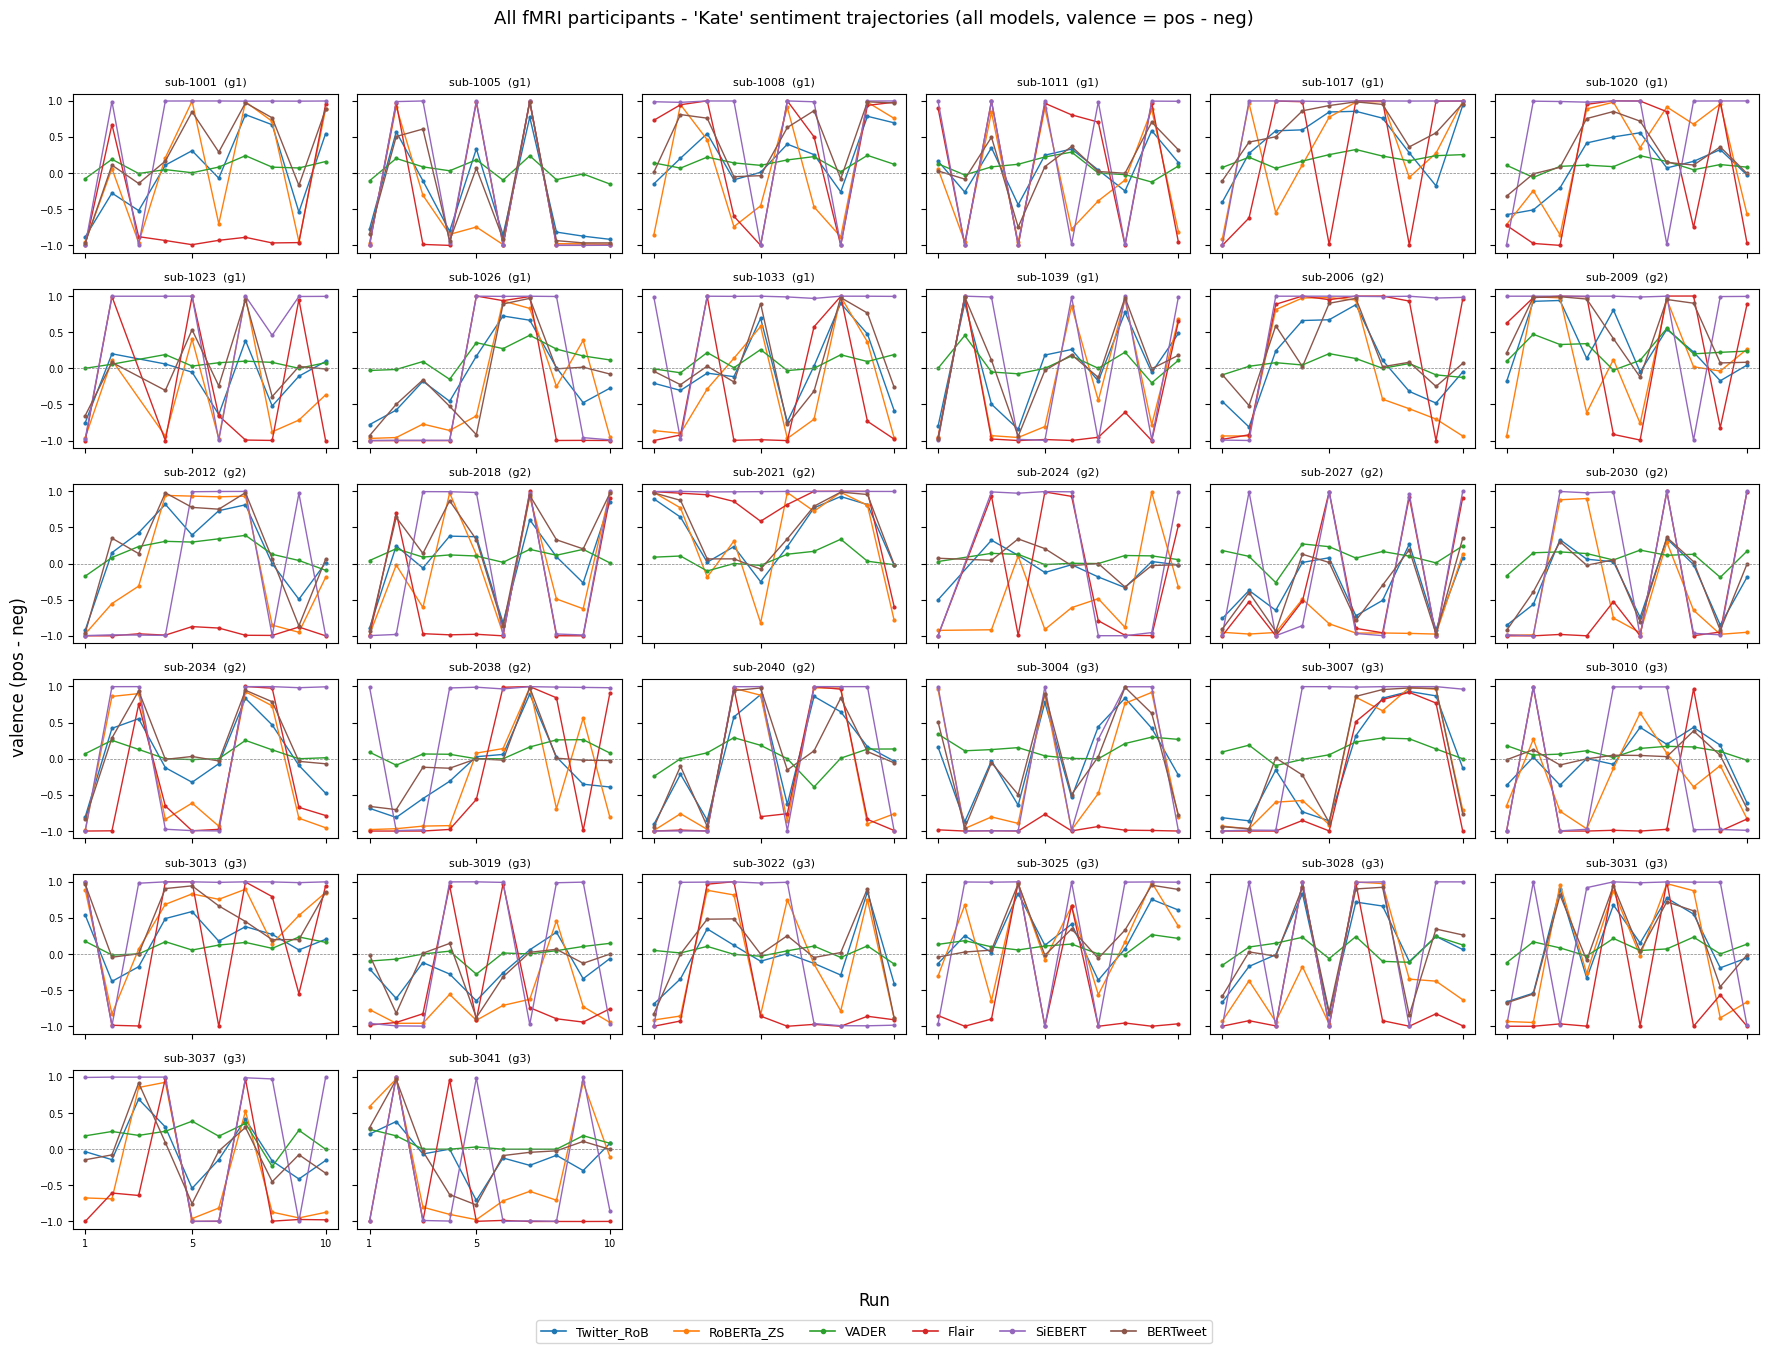

saved contact sheet for kate: 32 participants


In [15]:
# 0.4c(ii) Contact sheet -- all participants, one character (former 02 section 2.1c).
# One mini-panel per fMRI participant, tiled into a grid. Self-contained (reuses `scored`
# above; re-run the per-participant cell first if running this one in isolation).
CONTACT_CHAR = "kate"     # change to jack / kevin / randall for other cohorts
sc = scored[scored.Character == CONTACT_CHAR].copy()
pids = sorted(sc.Participant.unique(), key=lambda p: (_grp(p), p))   # group then id
ncol = 6; nrow = int(np.ceil(len(pids) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0*ncol, 2.2*nrow), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)
for ax, pid in zip(axes, pids):
    p = sc[sc.Participant == pid].sort_values("Run"); gp = int(p.group.iloc[0])
    for m in CLASSIFIERS:
        ax.plot(p.Run, p[f"val_{m}"], marker="o", ms=2, lw=1.0, color=mcolors[m])
    ax.axhline(0, color="grey", lw=0.5, ls="--")
    ax.set_title(f"{pid}  (g{gp})", fontsize=8); ax.set_xticks([1, 5, 10]); ax.tick_params(labelsize=7)
for ax in axes[len(pids):]: ax.axis("off")
handles = [plt.Line2D([0],[0], color=mcolors[m], marker="o", ms=3, lw=1.2) for m in CLASSIFIERS]
fig.legend(handles, CLASSIFIERS, loc="lower center", ncol=min(len(CLASSIFIERS),6), fontsize=9,
           bbox_to_anchor=(0.5, -0.01))
fig.suptitle(f"All fMRI participants - '{CONTACT_CHAR.capitalize()}' sentiment trajectories "
             f"(all models, valence = pos - neg)", fontsize=13, y=1.005)
fig.supxlabel("Run", y=0.02); fig.supylabel("valence (pos - neg)")
fig.tight_layout(rect=[0.01, 0.03, 1, 0.99])
fig.savefig(FIG_DIR / f"00__contactsheet_{CONTACT_CHAR}.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved contact sheet for {CONTACT_CHAR}: {len(pids)} participants")

**Mean +/- SEM per character** (former 2.2).

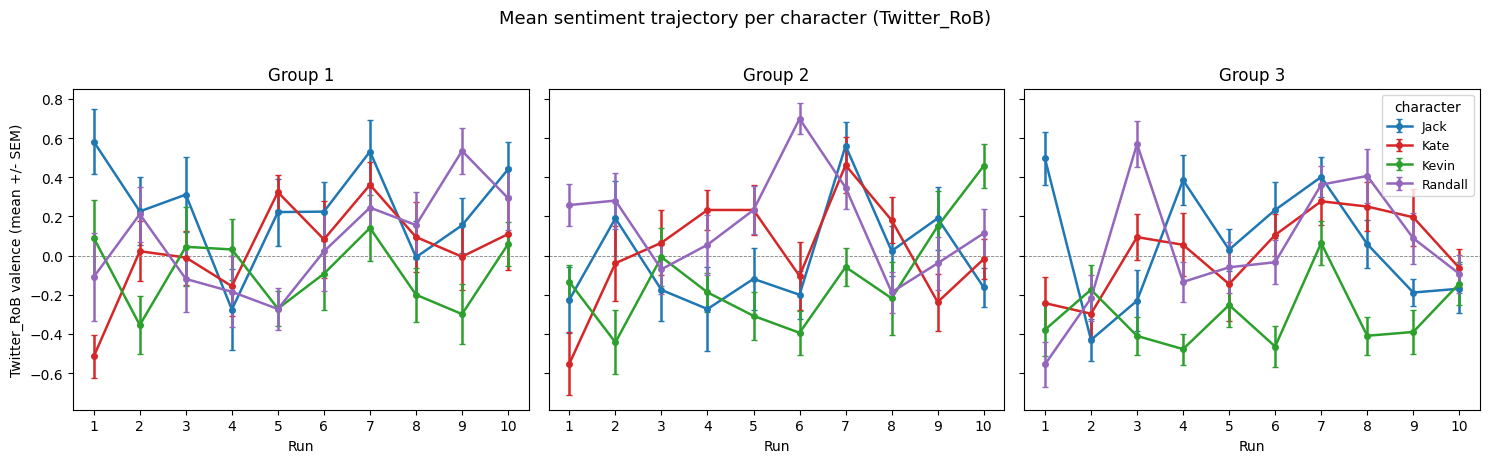

saved 00__mean_errorbar.png


In [16]:
# 0.4c(iii) Mean +/- SEM trajectories per character 
# Group-mean winner-model sentiment across runs, SEM error bars, four characters overlaid.
# Self-contained: loads results/baselines/00__character_vectors_simple_Twitter_RoB.csv.
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
MODEL = "Twitter_RoB"; CHARACTERS = ["jack","kate","kevin","randall"]; GROUPS = [1,2,3]
FIG_DIR = Path("results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
def _grp(pid):
    d = [c for c in str(pid) if c.isdigit()]; return int(d[0]) if d else np.nan
def sem(a):
    a = np.asarray(a, float); a = a[~np.isnan(a)]
    return a.std(ddof=1)/np.sqrt(len(a)) if len(a) > 1 else np.nan

_d = pd.read_csv(f"results/baselines/00__character_vectors_simple_{MODEL}.csv")
_d["Character"] = _d["Character"].str.lower().str.strip()
_d["valence"] = _d["positive"] - _d["negative"]; _d["group"] = _d["Participant"].map(_grp)
vsent = _d[_d["Run"].between(1,10)][["Participant","group","Character","Run","valence"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
colors = dict(zip(CHARACTERS, ["#1f77b4","#d62728","#2ca02c","#9467bd"]))
for ax, gp in zip(axes, GROUPS):
    for ch in CHARACTERS:
        sub = vsent[(vsent.Character==ch) & (vsent.group==gp)]
        stat = sub.groupby("Run")["valence"].agg(["mean", sem]).reset_index()
        ax.errorbar(stat.Run, stat["mean"], yerr=stat["sem"], marker="o", ms=4,
                    lw=1.8, capsize=2, color=colors[ch], label=ch.capitalize())
    ax.axhline(0, color="gray", lw=0.6, ls="--")
    ax.set_title(f"Group {gp}"); ax.set_xlabel("Run"); ax.set_xticks(range(1,11))
axes[0].set_ylabel(f"{MODEL} valence (mean +/- SEM)")
axes[-1].legend(fontsize=9, title="character")
fig.suptitle(f"Mean sentiment trajectory per character ({MODEL})", fontsize=13, y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR/"00__mean_errorbar.png", dpi=140, bbox_inches="tight")
plt.show(); print("saved 00__mean_errorbar.png")

**Cross-character z-scoring**

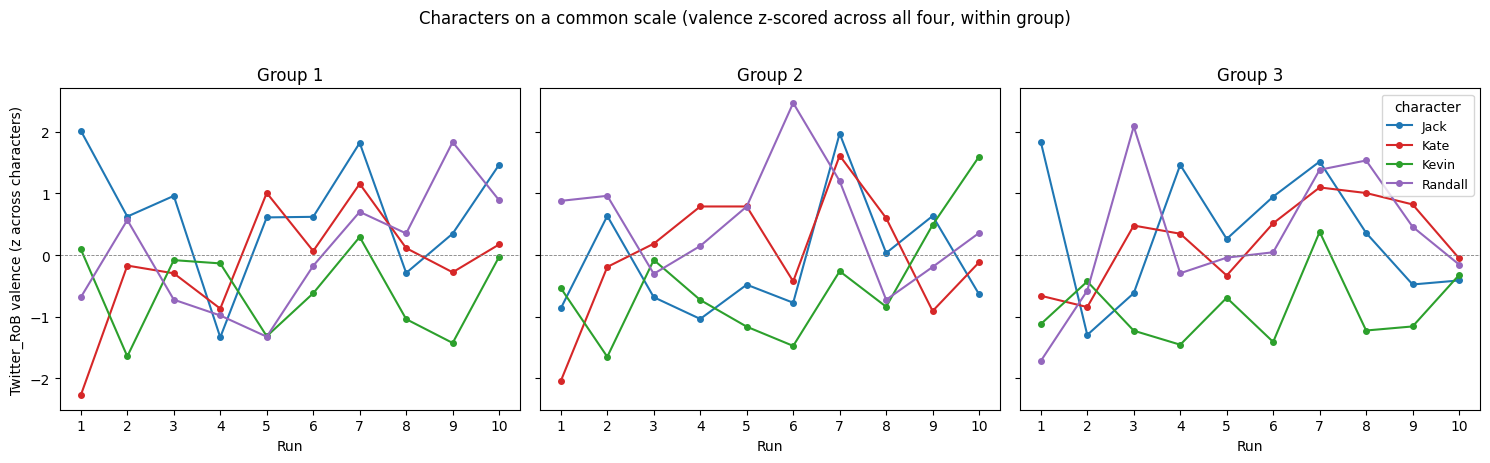

Mean valence (z across characters, pooled) per character -- negative = generally lower:
Character
kevin     -0.64
kate       0.04
randall    0.29
jack       0.31


In [17]:
# 0.4c(iv) Characters on a common scale -- cross-character z-scoring (former 02 section 2.2b).
# Pool all four characters within a group and z-score, to ask whether a character is genuinely
# lower than the others rather than only low within its own range. Self-contained.
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
MODEL = "Twitter_RoB"; CHARACTERS = ["jack","kate","kevin","randall"]; GROUPS = [1,2,3]
FIG_DIR = Path("results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
def _grp(pid):
    d = [c for c in str(pid) if c.isdigit()]; return int(d[0]) if d else np.nan
_d = pd.read_csv(f"results/baselines/00__character_vectors_simple_{MODEL}.csv")
_d["Character"] = _d["Character"].str.lower().str.strip()
_d["valence"] = _d["positive"] - _d["negative"]; _d["group"] = _d["Participant"].map(_grp)
vsent = _d[_d["Run"].between(1,10)][["Participant","group","Character","Run","valence"]]

mgc = vsent.groupby(["group","Character","Run"])["valence"].mean().reset_index()
_colors = dict(zip(CHARACTERS, ["#1f77b4","#d62728","#2ca02c","#9467bd"]))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, gp in zip(axes, GROUPS):
    sub = mgc[mgc.group==gp].copy()
    sub["z"] = (sub["valence"] - sub["valence"].mean()) / sub["valence"].std()
    for ch in CHARACTERS:
        s = sub[sub.Character==ch].sort_values("Run")
        ax.plot(s.Run, s["z"], marker="o", ms=4, color=_colors[ch], label=ch.capitalize())
    ax.axhline(0, color="gray", ls="--", lw=0.6); ax.set_title(f"Group {gp}")
    ax.set_xlabel("Run"); ax.set_xticks(range(1,11))
axes[0].set_ylabel(f"{MODEL} valence (z across characters)")
axes[-1].legend(fontsize=9, title="character")
fig.suptitle("Characters on a common scale (valence z-scored across all four, within group)", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR/"00__crosschar_zscored.png", dpi=140, bbox_inches="tight"); plt.show()
mz = (mgc.assign(z=mgc.groupby("group")["valence"].transform(lambda v:(v-v.mean())/v.std()))
         .groupby("Character")["z"].mean().sort_values())
print("Mean valence (z across characters, pooled) per character -- negative = generally lower:")
print(mz.round(2).to_string())

**Variance overview** 

 group  across_characters_SD  across_participants_SD
     1                 0.233                   0.496
     2                 0.266                   0.451
     3                 0.261                   0.395


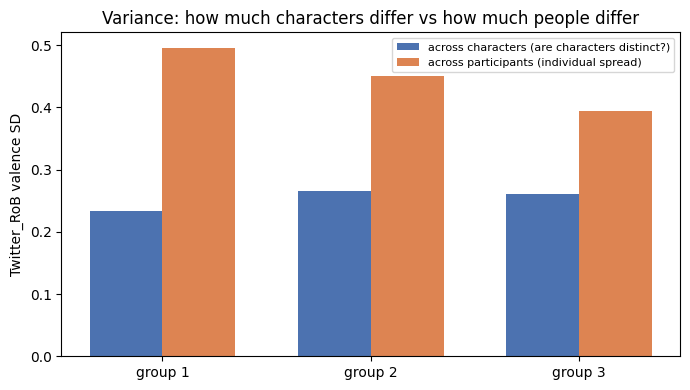

In [18]:
# 0.4c(v) Variance overview -- characters vs people (former 02 section 2.6).
# Within each group: how much do the four characters differ vs how much do participants differ.
# Self-contained: loads the winner-model baseline.
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
MODEL = "Twitter_RoB"; CHARACTERS = ["jack","kate","kevin","randall"]; GROUPS = [1,2,3]
FIG_DIR = Path("results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
def _grp(pid):
    d = [c for c in str(pid) if c.isdigit()]; return int(d[0]) if d else np.nan
_d = pd.read_csv(f"results/baselines/00__character_vectors_simple_{MODEL}.csv")
_d["Character"] = _d["Character"].str.lower().str.strip()
_d["valence"] = _d["positive"] - _d["negative"]; _d["group"] = _d["Participant"].map(_grp)
vsent = _d[_d["Run"].between(1,10)][["Participant","group","Character","Run","valence"]]

rows = []
for gp in GROUPS:
    sub = vsent[vsent.group==gp]
    across_char = sub.groupby(["Character","Run"])["valence"].mean().groupby(level="Run").std().mean()
    across_part = sub.groupby(["Character","Run"])["valence"].std().mean()
    rows.append({"group":gp, "across_characters_SD":round(across_char,3),
                 "across_participants_SD":round(across_part,3)})
vdf = pd.DataFrame(rows); print(vdf.to_string(index=False))
x = np.arange(len(GROUPS)); w = 0.35
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(x-w/2, vdf.across_characters_SD, w, label="across characters (are characters distinct?)", color="#4c72b0")
ax.bar(x+w/2, vdf.across_participants_SD, w, label="across participants (individual spread)", color="#dd8452")
ax.set_xticks(x); ax.set_xticklabels([f"group {g}" for g in GROUPS]); ax.set_ylabel(f"{MODEL} valence SD")
ax.set_title("Variance: how much characters differ vs how much people differ"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR/"00__variance_overview.png", dpi=140, bbox_inches="tight"); plt.show()

## 0.5 Build character profiles (per method)
**Primary object = the raw 10-run levels profile** 
 each row = what the participant thinks about the character at that run).

Two views are saved for the change-focused question:
- `*_centered`: each profile minus its own mean — removes baseline level, keeps the **shape** 
- `delta_profiles_*`: consecutive-run **changes** 

In [19]:
# === 0.5 Build CHARACTER PROFILES (per method) ===
# Methods / citations:
#  - Profiles -> RDM evaluation follows RSA: Kriegeskorte, Mur & Bandettini (2008,
#    Front. Syst. Neurosci. 2:4); social/affective RSA guide: Popal, Wang & Olson
#    (2019, SCAN 14(11):1243-1253).
#  - Run-to-run DELTAS / trajectory change on affective scores: Utterance Emotion
#    Dynamics, Hipson & Mohammad (2021, PLOS ONE 16(9):e0256153).
#  - Mean-centering to isolate trajectory SHAPE (remove baseline level) is the standard
#    move before correlation-based RDMs (Walther et al., 2016, NeuroImage 137:188).
#  - Validate-then-test (pick baseline on behavior, NOT on the brain) to avoid
#    double-dipping: Kriegeskorte et al. (2009, Nat. Neurosci. 12:535).
# PRIMARY object = the raw 10-run LEVELS profile (what the mentors specified:
#   "10 runs per person", "every row is what the participant thinks about the character").
# We ALSO produce two derived views for the change-focused research question.
# Levels are primary; centered/deltas are clearly-labeled transformations OF it.
#
# Per method, three files (long form, inspectable):
#   profiles_<m>.csv          PRIMARY  : raw run-resolved levels (up to 10 rows / profile)
#   profiles_<m>_centered.csv DERIVED  : each profile minus its own per-(P,char) mean
#                                        -> removes baseline level, keeps SHAPE (10 rows)
#   delta_profiles_<m>.csv    DERIVED  : consecutive-run changes (9 per full profile)
#
# Order = experienced Run order, within group. Missing runs: centering uses present
# runs; deltas are taken only across ADJACENT present runs (a gap yields no delta).

def build_profiles(score_df, feature_cols, method):
    import os
    os.makedirs("results/profiles", exist_ok=True); os.makedirs("results/deltas", exist_ok=True)
    # PRIMARY: raw levels (10 runs)
    levels = (score_df[["Participant","Run","Character"] + feature_cols]
              .dropna(subset=feature_cols, how="all")
              .sort_values(["Participant","Character","Run"]))
    levels.to_csv(f"results/profiles/00__profiles_{method}.csv", index=False)

    # DERIVED 1: mean-centered levels (10 runs, baseline removed -> shape) ----
    centered = levels.copy()
    centered[feature_cols] = (
        centered.groupby(["Participant","Character"])[feature_cols]
                .transform(lambda x: x - x.mean()))
    centered.to_csv(f"results/profiles/00__profiles_{method}_centered.csv", index=False)

    # DERIVED 2: entry-level run-to-run deltas (9 per full profile) 
    delta_rows = []
    for (p, ch), g in levels.groupby(["Participant","Character"]):
        g = g.sort_values("Run"); runs = g["Run"].tolist()
        X = g[feature_cols].to_numpy(dtype=float)
        for k in range(1, len(runs)):
            row = {"Participant": p, "Character": ch,
                   "Run_from": runs[k-1], "Run_to": runs[k]}
            row.update({f"d_{c}": (X[k]-X[k-1])[j] for j, c in enumerate(feature_cols)})
            delta_rows.append(row)
    deltas = pd.DataFrame(delta_rows)
    deltas.to_csv(f"results/deltas/00__delta_profiles_{method}.csv", index=False)
    return levels, centered, deltas

# classifiers: features = [pos, neg]
for m in MODELS:
    lv, ce, dl = build_profiles(scored, [f"{m}_pos", f"{m}_neg"], m)
    print(f"{m:14s} levels {lv.shape}  centered {ce.shape}  deltas {dl.shape}")


Twitter_RoB    levels (1272, 5)  centered (1272, 5)  deltas (1144, 6)
RoBERTa_ZS     levels (1272, 5)  centered (1272, 5)  deltas (1144, 6)
VADER          levels (1272, 5)  centered (1272, 5)  deltas (1144, 6)
Flair          levels (1272, 5)  centered (1272, 5)  deltas (1144, 6)
SiEBERT        levels (1272, 5)  centered (1272, 5)  deltas (1144, 6)
BERTweet       levels (1272, 5)  centered (1272, 5)  deltas (1144, 6)


## 0.6 (WHAT IS NEXTTTT) 
Run-vectors → stack into profiles → validate profiles against group-level behavioral ground truth (next step) → feed validated profiles into the brain/RSA analysis (does across-run sentiment change track neural change?)

## 0.7 · Reliability of the sentiment measure (added — belongs at construction)

Psychometric reliability of the score should be established where the measure is built, not
discovered later at the brain stage. Split-half over runs (odd vs even), Spearman-Brown corrected,
at three levels — because reliability drops predictably as you move from the value to its derived
quantities, and that gradient explains the whole downstream arc:

- **the measure** (mean valence per subject x character) — what Step 1 validates
- **the similarity structure** (subject-pair similarity per character) — what IS-RSA consumes; its ceiling
- *the change score* (run-to-run |delta|) — reported elsewhere; note it is split-dependent / unstable, so no single value is claimed

> [!note] Result (Twitter-RoBERTa; all models in the table)
> **measure SB = 0.685** (reliable — this is why the Step-1 cv-R² = 0.34 is attainable).
> **similarity-structure SB = 0.229** (this, not the measure, is the ceiling on any IS-RSA effect).
> The measure is sound; the low IS-RSA ceiling is an inherent property of subject-pair *similarity*
> derived from it, not a defect in the scoring.


In [20]:
import pandas as pd, numpy as np, re
from scipy.stats import spearmanr
sc=pd.read_csv("results/scored/00__reflection_sentiment.csv")
sc["pid"]=sc.Participant.map(lambda s: re.sub(r"\\D","",str(s))); sc["Character"]=sc.Character.str.lower().str.strip()
MODELS={"Twitter_RoB":("Twitter_RoB_pos","Twitter_RoB_neg"),"RoBERTa_ZS":("RoBERTa_ZS_pos","RoBERTa_ZS_neg"),
        "VADER":("VADER_pos","VADER_neg"),"Flair":("Flair_pos","Flair_neg"),
        "SiEBERT":("SiEBERT_pos","SiEBERT_neg"),"BERTweet":("BERTweet_pos","BERTweet_neg")}
sb=lambda r:(2*r)/(1+r) if r>-1 else np.nan
print("MEASURE reliability (mean valence per subject x character), odd/even runs, Spearman-Brown:")
for m,(pc,nc) in MODELS.items():
    sc["val"]=sc[pc]-sc[nc]; odd,even=[],[]
    for (p,ch),g in sc.groupby(["pid","Character"]):
        o,e=g[g.Run%2==1]["val"],g[g.Run%2==0]["val"]
        if len(o) and len(e): odd.append(o.mean()); even.append(e.mean())
    r=spearmanr(odd,even)[0]; print(f"   {m:12s} r={r:.3f}  SB={sb(r):.3f}")
# similarity-structure reliability (winner), the IS-RSA ceiling
sc["val"]=sc["Twitter_RoB_pos"]-sc["Twitter_RoB_neg"]
def simvec(half):
    out=[]
    for ch in ["jack","kate","randall","kevin"]:
        v=np.array([ (lambda x: x.mean() if len(x) else np.nan)(sc[(sc.pid==p)&(sc.Character==ch)&(sc.Run%2==half)]["val"]) for p in sorted(sc.pid.unique())])
        out+=[-abs(v[i]-v[j]) for i in range(len(v)) for j in range(i+1,len(v))]
    return np.array(out)
a,b=simvec(1),simvec(0); mask=np.isfinite(a)&np.isfinite(b); rs=spearmanr(a[mask],b[mask])[0]
print(f"\nSIMILARITY-STRUCTURE reliability (Twitter_RoB): r={rs:.3f}  SB={sb(rs):.3f}  <- the IS-RSA ceiling")
np.save("results/step0/00__reliability.npy",{"measure_SB":sb(spearmanr(odd,even)[0]),"structure_SB":sb(rs)},allow_pickle=True) if __import__("os").path.isdir("results/step0") else print("(note: results/step0 dir absent; not saved)")


MEASURE reliability (mean valence per subject x character), odd/even runs, Spearman-Brown:
   Twitter_RoB  r=0.521  SB=0.685
   RoBERTa_ZS   r=0.466  SB=0.635
   VADER        r=0.353  SB=0.522
   Flair        r=0.505  SB=0.671
   SiEBERT      r=0.364  SB=0.534
   BERTweet     r=0.517  SB=0.682

SIMILARITY-STRUCTURE reliability (Twitter_RoB): r=0.130  SB=0.229  <- the IS-RSA ceiling
(note: results/step0 dir absent; not saved)
